The same dataset used in the EDA phase is reused here to ensure consistency and continuity in the data analysis process.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Walmart_Sales.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [4]:
df.dtypes

,0
Store,int64
Date,object
Weekly_Sales,float64
Holiday_Flag,int64
Temperature,float64
Fuel_Price,float64
CPI,float64
Unemployment,float64


In [5]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Task 1: Identify Data Quality Issues

In [6]:
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


np.int64(0)

The dataset was assessed for potential data quality issues. No missing values or duplicate records were identified. The data types are appropriate, with numerical features correctly represented and the Date column properly formatted as a datetime variable.

#Task 2: Missing Value Strategy

In [14]:
df_filled = df.copy()

df_filled['CPI'] = df_filled['CPI'].fillna(df_filled['CPI'].mean())

#Task 3: Outliers using IQR

In [10]:
Q1 = df['Weekly_Sales'].quantile(0.25)
Q3 = df['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Weekly_Sales'] < lower_bound) | (df['Weekly_Sales'] > upper_bound)]
outliers.shape

(34, 8)

In [15]:
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 553350.105
Q3: 1420158.66
IQR: 866808.5549999999
Lower Bound: -746862.7275
Upper Bound: 2720371.4924999997


In [16]:
outliers = df[(df['Weekly_Sales'] < lower_bound) | (df['Weekly_Sales'] > upper_bound)]

print("Number of outliers:", outliers.shape[0])
outliers.head()

Number of outliers: 34


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
189,2,2010-12-24,3436007.68,0,49.97,2.886,211.064660,8.163
241,2,2011-12-23,3224369.80,0,46.66,3.112,218.999550,7.441
471,4,2010-11-26,2789469.45,1,48.08,2.752,126.669267,7.127
474,4,2010-12-17,2740057.14,0,46.57,2.884,126.879484,7.127
475,4,2010-12-24,3526713.39,0,43.21,2.887,126.983581,7.127


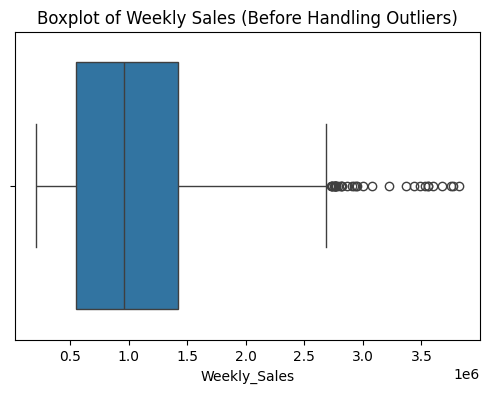

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x=df['Weekly_Sales'])
plt.title("Boxplot of Weekly Sales (Before Handling Outliers)")
plt.show()

In [18]:
df_no_outliers = df[(df['Weekly_Sales'] >= lower_bound) & (df['Weekly_Sales'] <= upper_bound)]

Outliers were detected using the Interquartile Range (IQR) method by calculating the first quartile (Q1), third quartile (Q3), and the IQR value. Lower and upper bounds were defined to identify extreme values. The number of outliers was reported, and a boxplot was used to visually confirm their presence. Outliers were then removed to improve data quality and ensure more reliable analysis.

#Task 4: Normalization

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_minmax = df.copy()

df_minmax[['Weekly_Sales']] = scaler.fit_transform(df_minmax[['Weekly_Sales']])

 Z-score Standardization

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_zscore = df.copy()

df_zscore[['Weekly_Sales']] = scaler.fit_transform(df_zscore[['Weekly_Sales']])

In [19]:
print("Original:")
print(df['Weekly_Sales'].head())

print("\nMin-Max Scaled:")
print(df_minmax['Weekly_Sales'].head())

print("\nZ-score Standardized:")
print(df_zscore['Weekly_Sales'].head())

Original:
0    1643690.90
1    1641957.44
2    1611968.17
3    1409727.59
4    1554806.68
Name: Weekly_Sales, dtype: float64

Min-Max Scaled:
0    0.397291
1    0.396811
2    0.388501
3    0.332458
4    0.372661
Name: Weekly_Sales, dtype: float64

Z-score Standardized:
0    1.057420
1    1.054348
2    1.001206
3    0.642828
4    0.899914
Name: Weekly_Sales, dtype: float64


Two normalization techniques were applied to the Weekly_Sales feature. Min-Max scaling transformed the values to a range between 0 and 1, while Z-score standardization centered the data around the mean with a standard deviation of one. These transformations help improve data comparability and are important for machine learning models.

#Task 5: PCA

In [20]:
df.corr()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Store,1.000000e+00,1.577299e-13,-0.335332,-4.386841e-16,-0.022659,0.060023,-0.209492,0.223531
Date,1.577299e-13,1.000000e+00,0.006949,-1.328524e-02,0.145357,0.771444,0.077157,-0.248203
Weekly_Sales,-3.353320e-01,6.949360e-03,1.000000,3.689097e-02,-0.063810,0.009464,-0.072634,-0.106176
Holiday_Flag,-4.386841e-16,-1.328524e-02,0.036891,1.000000e+00,-0.155091,-0.078347,-0.002162,0.010960
Temperature,-2.265908e-02,1.453566e-01,-0.063810,-1.550913e-01,1.000000,0.144982,0.176888,0.101158
Fuel_Price,6.002295e-02,7.714439e-01,0.009464,-7.834652e-02,0.144982,1.000000,-0.170642,-0.034684
CPI,-2.094919e-01,7.715746e-02,-0.072634,-2.162091e-03,0.176888,-0.170642,1.000000,-0.302020
Unemployment,2.235313e-01,-2.482029e-01,-0.106176,1.096028e-02,0.101158,-0.034684,-0.302020,1.000000


In [21]:
features = df[['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']]

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

In [25]:
import pandas as pd

pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
pca_df.head()

,PC1,PC2
0,1.092458,-1.596603
1,1.091952,-1.790889
2,1.119835,-1.771110
3,1.123303,-1.421490
4,1.084853,-1.347668


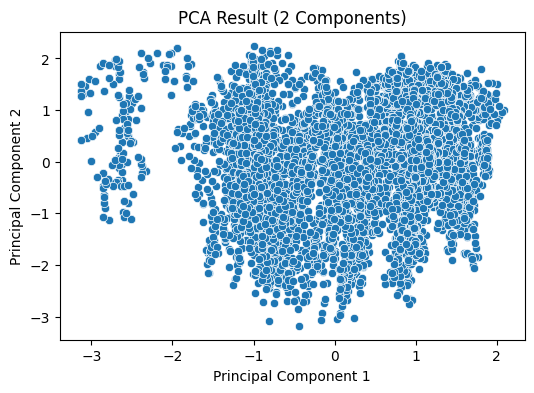

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.scatterplot(x='PC1', y='PC2', data=pca_df)
plt.title("PCA Result (2 Components)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [27]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.33365397 0.28720875]


The explained variance ratio indicates how much variance is captured by each principal component.

Principal Component Analysis (PCA) was applied after standardizing the selected numerical features. Two principal components were generated to reduce the dimensionality of the dataset. The explained variance ratio was examined to evaluate how much information is retained by each component.

The correlation analysis indicated that relationships between the features are relatively weak; therefore, PCA may not provide significant dimensionality reduction benefits in this case. However, it was applied for demonstration purposes to illustrate the technique and its effect on the data representation.